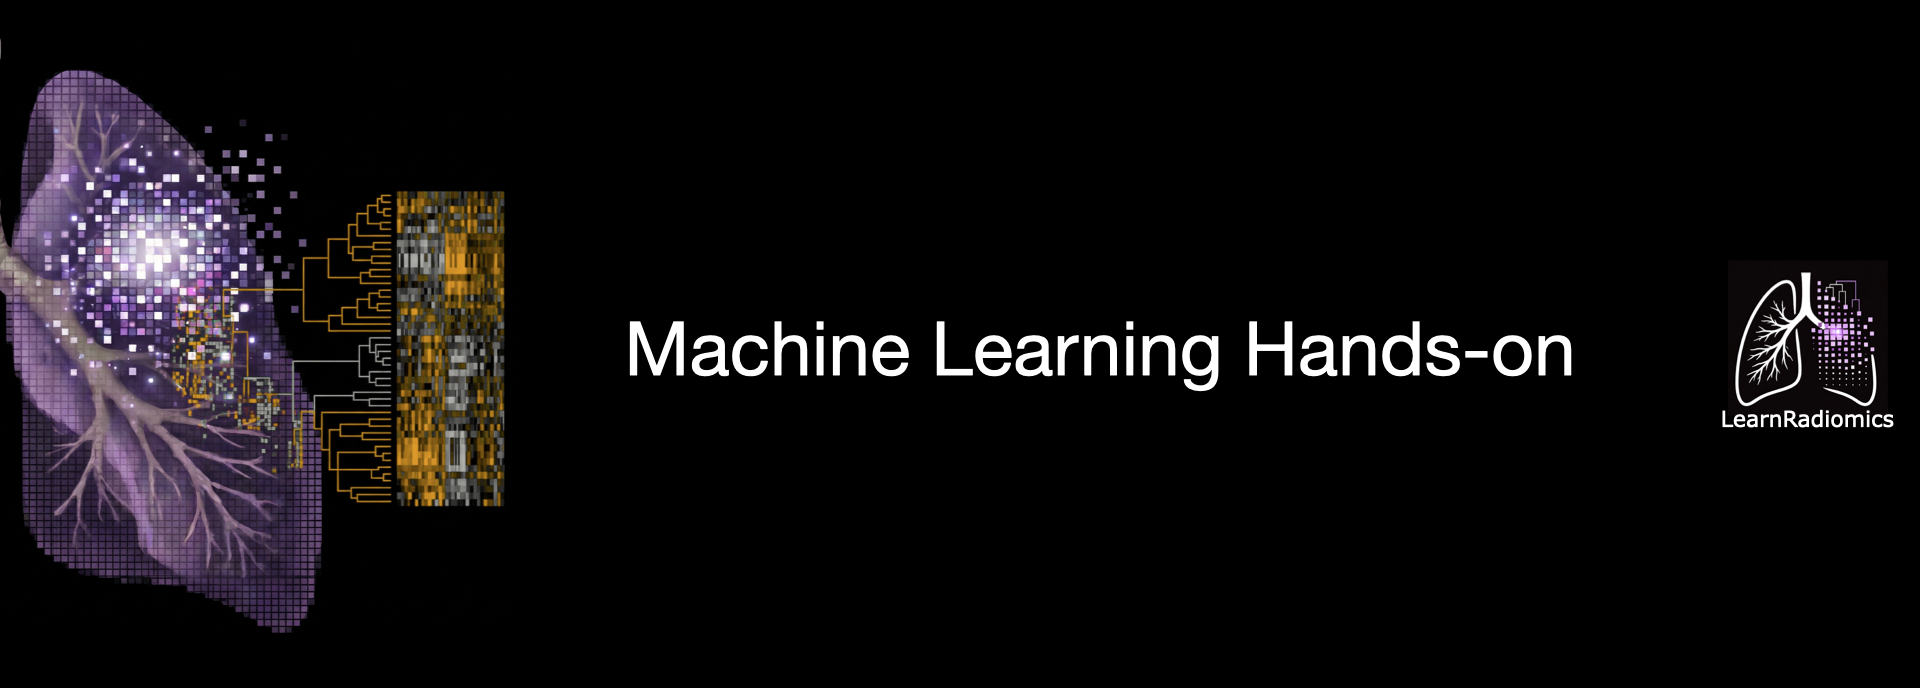

In [ ]:
! pip install scikit-optimize

In [ ]:
## General libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from collections import Counter

## Data visualization
from plotnine import *
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

## Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Ridge, RidgeCV, LogisticRegressionCV

import sys
sys.modules['sklearn.externals.joblib'] = joblib

## Statistical tool libraries
from scipy import stats
from scipy.stats import mannwhitneyu, shapiro, chi2_contingency
import statsmodels.api as sm
import sklearn.metrics as mt
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.metrics import accuracy_score as acc
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV,StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
import itertools
from skopt import BayesSearchCV
from imblearn.over_sampling import SMOTENC, SMOTE


## Time and workflow
import time
from tqdm import trange

## Sistema
import warnings
warnings.filterwarnings("ignore", category = FutureWarning)


In [ ]:
### Functions used later
def plot_confusion_matrix_sklearn(
    y_true,
    y_pred,
    labels=None,
    display_labels=None,
    normalize=None,
    title="Confusion Matrix",
    cmap="Blues",
    figsize=(6, 6),
    values_format=None
):
    """
    Plot a confusion matrix using sklearn and matplotlib.

    Parameters
    ----------
    y_true : array-like
        True labels.
    y_pred : array-like
        Predicted labels.
    labels : array-like, optional
        List of labels to index the matrix. Useful to control class order.
    display_labels : array-like, optional
        Labels shown on axes.
    normalize : {'true', 'pred', 'all'}, optional
        Normalization mode for confusion_matrix.
    title : str
        Plot title.
    cmap : str
        Matplotlib colormap.
    figsize : tuple
        Figure size.
    values_format : str, optional
        Format for displayed values, e.g. ".2f" for normalized values.

    Returns
    -------
    cm : ndarray
        Confusion matrix values.
    """
    cm = confusion_matrix(
        y_true=y_true,
        y_pred=y_pred,
        labels=labels,
        normalize=normalize
    )

    fig, ax = plt.subplots(figsize=figsize)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_labels if display_labels is not None else labels
    )

    disp.plot(
        ax=ax,
        cmap=cmap,
        values_format=values_format,
        colorbar=False
    )

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return cm

In [ ]:
def univariate_logistic_repeated_auc_scaled(
    df,
    target_col,
    feature_cols,
    n_splits=30,
    test_size=0.30,
    random_state=42,
    scaler_method='standard',
    min_train_n=20,
    min_test_n=10,
    dropna=True,
    verbose=False
):
    """
    Iterative evaluation of univariate logistic regression for multiple variables
    using StratifiedShuffleSplit, scaling fit only on the training set, and test-set AUC.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con target y predictores.
    target_col : str
        Name of the binary target variable (0/1).
    feature_cols : list
        List of numerical predictor variables to evaluate.
    n_splits : int
        Number of repeated splits.
    test_size : float
        Proportion of the test set.
    random_state : int
        Seed for reproducibility.
    scaler_method : str
        'standard', 'minmax', or 'robust'.
    min_train_n : int
        Minimum number of observations required in the training set.
    min_test_n : int
        Minimum number of observations required in the test set.
    dropna : bool
        If True, drops NA values in each split and for each variable.
    verbose : bool
        If True, prints errors.

    Returns
    -------
    results_df : pd.DataFrame
        Summary by variable.
    """

    # Scaler selection
    if scaler_method == 'standard':
        scaler_class = StandardScaler
    elif scaler_method == 'minmax':
        scaler_class = MinMaxScaler
    elif scaler_method == 'robust':
        scaler_class = RobustScaler
    else:
        raise ValueError("scaler_method must be 'standard', 'minmax', or 'robust'")

    y_global = df[target_col].values

    splitter = StratifiedShuffleSplit(
        n_splits=n_splits,
        test_size=test_size,
        random_state=random_state
    )

    results = []

    for feature in feature_cols:
        aucs = []
        betas = []
        ors = []
        pvals = []
        ci_lows = []
        ci_highs = []

        n_train_list = []
        n_test_list = []

        failed_splits = 0

        for split_number, (train_idx, test_idx) in enumerate(splitter.split(df, y_global), start=1):
            try:
                data_train = df.iloc[train_idx][[target_col, feature]].copy()
                data_test = df.iloc[test_idx][[target_col, feature]].copy()

                if dropna:
                    data_train = data_train.dropna()
                    data_test = data_test.dropna()

                n_train = len(data_train)
                n_test = len(data_test)

                n_train_list.append(n_train)
                n_test_list.append(n_test)

                # Minimum checks
                if n_train < min_train_n or n_test < min_test_n:
                    failed_splits += 1
                    continue

                # Verify binary target in both splits
                if data_train[target_col].nunique() != 2:
                    failed_splits += 1
                    continue

                if data_test[target_col].nunique() != 2:
                    failed_splits += 1
                    continue

                # Verify predictor variability
                if data_train[feature].nunique() < 2:
                    failed_splits += 1
                    continue

                # Scaling fit only on the training set
                scaler = scaler_class()

                X_train_raw = data_train[[feature]].astype(float)
                X_test_raw = data_test[[feature]].astype(float)

                X_train_scaled = scaler.fit_transform(X_train_raw)
                X_test_scaled = scaler.transform(X_test_raw)

                X_train_scaled = pd.DataFrame(
                    X_train_scaled,
                    columns=[feature],
                    index=data_train.index
                )
                X_test_scaled = pd.DataFrame(
                    X_test_scaled,
                    columns=[feature],
                    index=data_test.index
                )

                y_train = data_train[target_col]
                y_test = data_test[target_col]

                # Logistic fit
                X_train_model = sm.add_constant(X_train_scaled)
                fit = sm.Logit(y_train, X_train_model).fit(method='lbfgs',
                                                           maxiter=200,disp=0,warn_convergence=False)


                # verify actual convergence
                if not getattr(fit, 'mle_retvals', {}).get('converged', True):
                    raise RuntimeError('model_not_converged')


                beta = fit.params[feature]
                p_value = fit.pvalues[feature]
                ci_low, ci_high = fit.conf_int().loc[feature]

                # Prediction on the test set
                X_test_model = sm.add_constant(X_test_scaled, has_constant='add')
                y_prob_test = fit.predict(X_test_model)
                auc_test = roc_auc_score(y_test, y_prob_test)

                aucs.append(auc_test)
                betas.append(beta)
                ors.append(np.exp(beta))
                pvals.append(p_value)
                ci_lows.append(np.exp(ci_low))
                ci_highs.append(np.exp(ci_high))

            except Exception as e:
                failed_splits += 1
                if verbose:
                    print(f'Error in variable {feature}, split {split_number}: {e}')
                continue

        successful_splits = len(aucs)

        if successful_splits == 0:
            results.append({
                'feature': feature,
                'mean_AUC_test': np.nan,
                'std_AUC_test': np.nan,
                'median_AUC_test': np.nan,
                'mean_beta_train': np.nan,
                'mean_OR_train': np.nan,
                'median_p_value_train': np.nan,
                'mean_CI95_low_train': np.nan,
                'mean_CI95_high_train': np.nan,
                'mean_n_train': np.nan if len(n_train_list) == 0 else np.mean(n_train_list),
                'mean_n_test': np.nan if len(n_test_list) == 0 else np.mean(n_test_list),
                'successful_splits': 0,
                'failed_splits': failed_splits,
                'scaler': scaler_method,
                'status': 'no_valid_fit'
            })
        else:
            results.append({
                'feature': feature,
                'mean_AUC_test': np.mean(aucs),
                'std_AUC_test': np.std(aucs),
                'median_AUC_test': np.median(aucs),
                'mean_beta_train': np.mean(betas),
                'mean_OR_train': np.mean(ors),
                'median_p_value_train': np.median(pvals),
                'mean_CI95_low_train': np.mean(ci_lows),
                'mean_CI95_high_train': np.mean(ci_highs),
                'mean_n_train': np.mean(n_train_list) if len(n_train_list) > 0 else np.nan,
                'mean_n_test': np.mean(n_test_list) if len(n_test_list) > 0 else np.nan,
                'successful_splits': successful_splits,
                'failed_splits': failed_splits,
                'scaler': scaler_method,
                'status': 'ok'
            })

    results_df = pd.DataFrame(results).sort_values(
        by=['mean_AUC_test', 'median_p_value_train'],
        ascending=[False, True],
        na_position='last'
    ).reset_index(drop=True)

    return results_df

def evaluate_metrics(y_true, y_pred):

    Acc= mt.accuracy_score(y_true,y_pred)
    F1 = mt.f1_score(y_true,y_pred, pos_label=1, average='binary',zero_division = 0)
    Precision = mt.precision_score(y_true,y_pred,pos_label=1,average="binary",zero_division = 0)
    Recall = mt.recall_score(y_true,y_pred,labels=[1],average=None,zero_division = 0)
    fpr, tpr, thresholds = mt.roc_curve(y_true,y_pred)
    Auc = mt.auc(fpr,tpr)

    return(Acc, F1, Precision, Recall, Auc)

def run_stratified_kfold (iterations, num_folds, X, y, model):

    results_df = pd.DataFrame()

    all_accuracy = []
    all_f1 = []
    all_precision = []
    all_recall = []
    all_auc = []

    for i in trange(iterations):

        skf = StratifiedKFold(n_splits=num_folds)
        for j, (train_index, test_index) in enumerate(skf.split(X, y)):
            X_train = X.iloc[train_index,:]
            y_train = y[train_index]
            X_test = X.iloc[test_index,:]
            y_test = y[test_index]

            model.fit(X_train, y_train)

            pred_test = model.predict(X_test)
            pred_train =model.predict(X_train)

            Acc, F1, Precision, Recall, Auc = evaluate_metrics(y_test, pred_test)

            all_accuracy.append(Acc)
            all_f1.append(F1)
            all_precision.append(Precision)
            all_recall.append(Recall[0])
            all_auc.append(Auc)

    results_df['accuracy'] = all_accuracy
    results_df['F1 score'] = all_f1
    results_df['Precision'] = all_precision
    results_df['Recall'] = all_recall
    results_df['AUC'] = all_auc

    return(results_df)

#### Data loading and preparation

In [ ]:
### Data loading

url = 'https://raw.githubusercontent.com/learnradiomics/modeling/main/data_radiomics_wfilters.xlsx'

df = pd.read_excel(url)

print(f'Number of patients: {df.shape[0]}')
print(f'Number of variables: {df.shape[1]}')

In [ ]:
df.columns[0:20]

In [ ]:
df_filters = df.drop(columns=['EGFR_mutation_status_Mutant'])

df_filters.insert(loc=0,
            column='EGFR_mutation_status_Mutant',
            value=df.EGFR_mutation_status_Mutant)

df_filters.head(3)

In [ ]:
for i in range(50):
    print(i, ':', df_filters.columns[i])

In [ ]:
original_features = ['EGFR_mutation_status_Mutant',  'Gender_Female',
                    'Ethnicity_Caucasian','Ethnicity_Native_Hawaiian/Pacific_Islander',
                    'Ethnicity_African_American', 'Ethnicity_Asian', 'Ethnicity_Hispanic/Latino',
                    'Smoking_status_Nonsmoker', 'Age_at_Histological_Diagnosis', 'Weight_(lbs)']

for feature in df_filters.columns:
    feature_class = (feature.split('_')[0])
    if feature_class == 'original':
        original_features.append(feature)
    else:
        continue


In [ ]:
data = df_filters.loc[:,original_features]
data.shape

### Hold-out split

In [ ]:
## Data split
X_train, X_test, y_train, y_test = train_test_split(data.iloc[:,1:],data.iloc[:,0],
                                                    test_size=0.3, random_state=25)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

print("EGFR mutant in train:", Counter(y_train))
print("EGFR mutant in test:", Counter(y_test))

### First model: Decision Tree

In [ ]:
## Decision tree:
seed = 25

depth = 3
model = DecisionTreeClassifier(max_depth=depth,random_state=seed)
model

In [ ]:
### The data are passed to the model and it is trained
model.fit(X_train, y_train)

In [ ]:
### Prediction on new data
y_pred = model.predict(X_test)
y_pred

In [ ]:
### Prediction on new data: score de probabilidad
y_pred_prob = model.predict_proba(X_test)
y_pred_prob[0:10]

#### Performance evaluation of the first model

In [ ]:
auc_test = roc_auc_score(y_test, y_pred_prob[:,1])

print(classification_report(y_test, y_pred))
print("TEST group AUC:", auc_test)

In [ ]:
# Confusion matrix
plot_confusion_matrix_sklearn(
    y_true=y_test,
    y_pred=y_pred,
    labels=[0, 1],
    display_labels=["EGFR wildtype", "EGFR mutant"],
    title="Confusion Matrix",
    cmap="Purples"
)

In [ ]:
auc_test = roc_auc_score(y_test, y_pred_prob[:,1])
print("AUC de grupo test:", auc_test)

#### Decision tree visualization

In [ ]:

### Tree visualization
class_names = ["EGFR wildtype", "EGFR mutant"]

plt.figure(figsize=(18, 8))

plot_tree(
    model,
    feature_names=X_train.columns,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=False,
    impurity=True
)

plt.title("Decision Tree Visualization")
plt.show()

#### Variable selection with univariate models

In [ ]:
### Running univariate logistic regression models for variable selection:

## Create a dataframe with X and y variables to run the univariate function
df_train = pd.DataFrame(X_train, columns=X_train.columns)
df_train.insert(loc=0,
               column= 'EGFR_mutation_status_Mutant',
               value= y_train)

target_col = 'EGFR_mutation_status_Mutant'

results_repeated_scaled = univariate_logistic_repeated_auc_scaled(
    df=df_train,
    target_col=target_col,
    feature_cols=df_train.columns[1:],
    n_splits=100, ## repetitions
    test_size=0.30,
    random_state=42,
    scaler_method='standard',  # 'standard', 'minmax', or 'robust'
    min_train_n=20,
    min_test_n=10,
    dropna=True,
    verbose=False
)

results_repeated_scaled.head(5)

In [ ]:
### Select variables using an AUC threshold on the test set
threshold = 0.6

features_univariate_filter = results_repeated_scaled[results_repeated_scaled.mean_AUC_test > threshold].feature.to_list()
print("Number of variables seleccionadas:",len(features_univariate_filter))
print("\n\nVariables:\n\n",features_univariate_filter)

In [ ]:
### New model with fewer variables:
## Data split
X_train, X_test, y_train, y_test = train_test_split(data.iloc[:,1:], data.iloc[:,0],
                                                    test_size=0.3, random_state=seed)

depth = 3
model = DecisionTreeClassifier(max_depth=depth,random_state=42)

### Prediction on new data
model.fit(X_train.loc[:,features_univariate_filter], y_train)
y_pred = model.predict(X_test.loc[:,features_univariate_filter])
y_pred_prob = model.predict_proba(X_test.loc[:,features_univariate_filter])

plot_confusion_matrix_sklearn(
    y_true=y_test,
    y_pred=y_pred,
    labels=[0, 1],
    display_labels=["EGFR wildtype", "EGFR mutant"],
    title="Confusion Matrix",
    cmap="Purples"
)

auc_test = roc_auc_score(y_test, y_pred_prob[:,1])
print("TEST group AUC:", auc_test)
print(classification_report(y_test, y_pred))


#### Impact of variable selection
* It was not significant.
* Decision trees perform automatic variable selection.
* Property: Feature Importance

In [ ]:
## Feature Importance
df_feature_importance = pd.DataFrame()
df_feature_importance['Feature'] = features_univariate_filter
df_feature_importance['Importance'] = model.feature_importances_
df_feature_importance = df_feature_importance.sort_values(
            by="Importance",
            ascending=False
        ).reset_index(drop=True)

df_feature_importance.head(15)

#### Hyperparameter optimization

In [ ]:
### The tree hyperparameters can take different values

params = {
        "max_depth":3 ,
        "min_samples_split": 2,   # sklearn requires >= 2
        "min_samples_leaf": 1,
        "criterion": 'gini',
        "max_features": None,
        "class_weight": 'balanced'}

model = DecisionTreeClassifier(**params, random_state=seed)

### Prediction on new data
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)


plot_confusion_matrix_sklearn(
    y_true=y_test,
    y_pred=y_pred,
    labels=[0, 1],
    display_labels=["EGFR wildtype", "EGFR mutant"],
    title="Confusion Matrix",
    cmap="Purples"
)

auc_test = roc_auc_score(y_test, y_pred_prob[:,1])
print(classification_report(y_test, y_pred))
print("TEST group AUC:", auc_test)



### El problema de la particion

In [ ]:
## Data split
X_train, X_test, y_train, y_test = train_test_split(data.iloc[:,1:], data.iloc[:,0],
                                                    test_size=0.3, random_state=seed)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

print("EGFR mutant in train:", Counter(y_train))
print("EGFR mutant in test:", Counter(y_test))
print("Case indices in X_train:", X_train.index[0:20])

#### Types of split

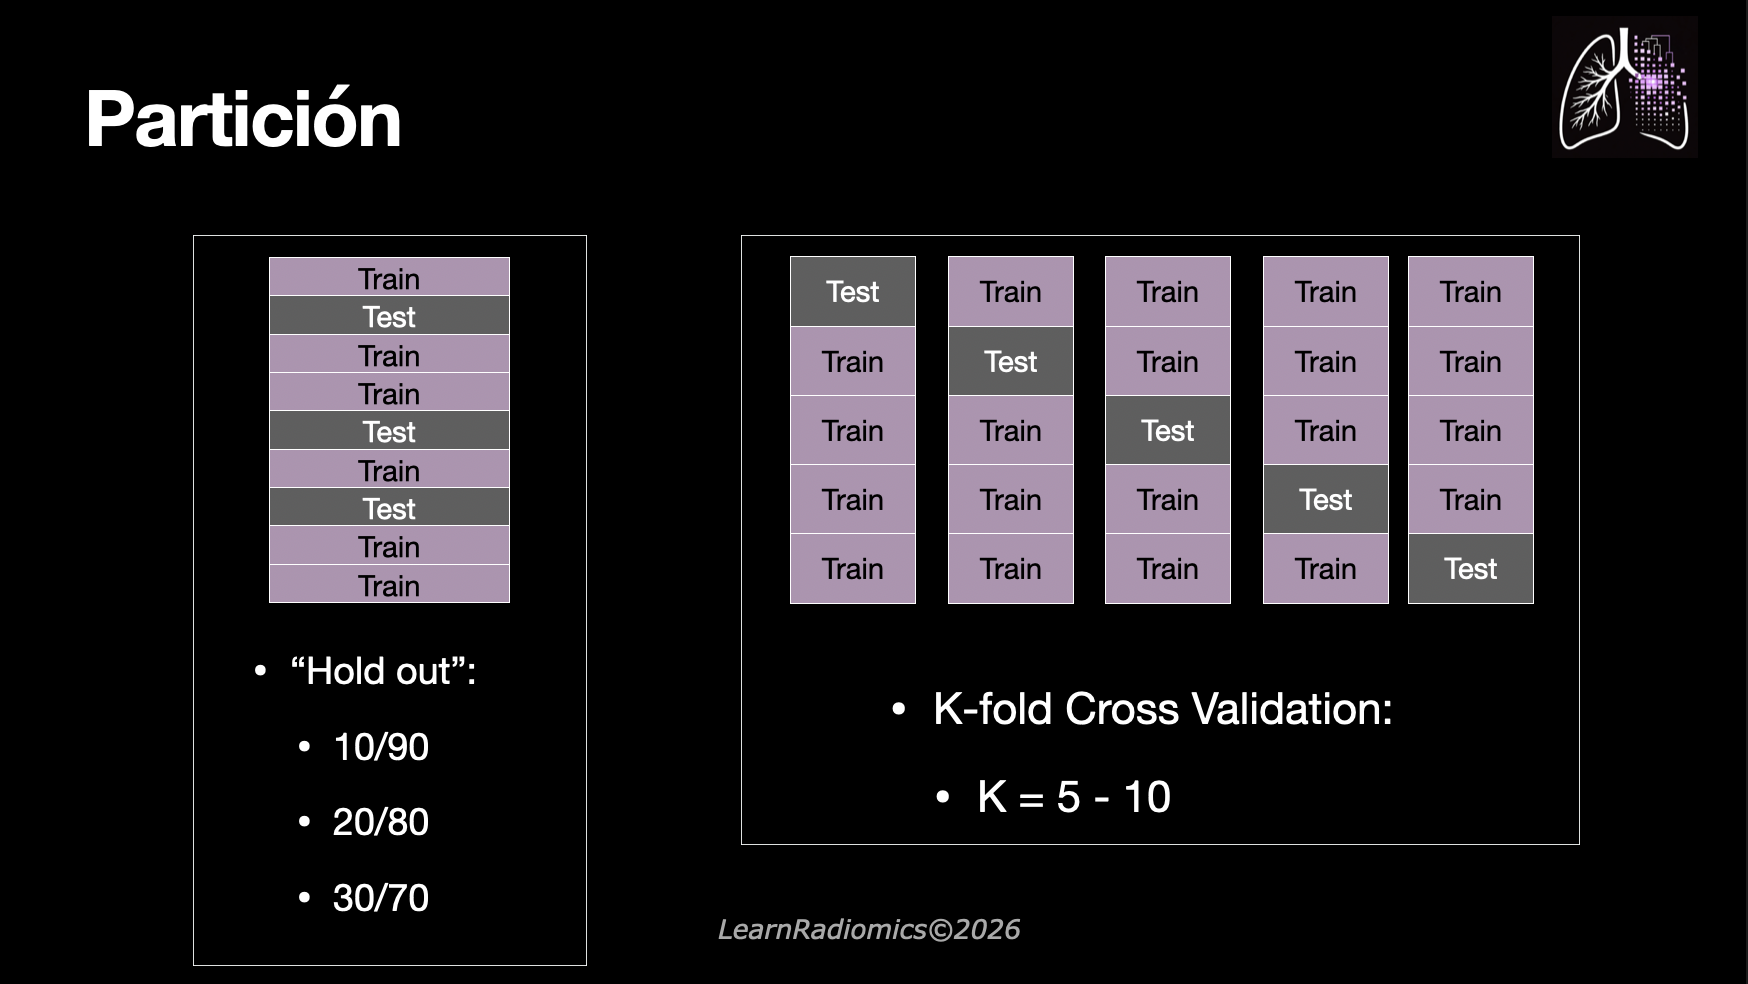

#### K-Fold cross-validation

In [ ]:
## KFold split
X = data.iloc[:,1:]
y = data.iloc[:,0]

k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=seed)


for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
    print(print(f"Fold: {fold_idx}, index: {val_idx}"))

#### Evaluation of model performance with k-fold

In [ ]:

k = 5

cv = KFold(n_splits=k, shuffle=True, random_state=15)

fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):

    X_train, X_val = X.iloc[train_idx,:], X.iloc[val_idx,:]
    y_train, y_val = y[train_idx], y[val_idx]

    model = DecisionTreeClassifier(**params, random_state=56)

    ### Prediction on new data
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_pred_prob = model.predict_proba(X_val)
    auc_val = roc_auc_score(y_val, y_pred_prob[:,1])
    fold_results.append(auc_val)
    print(f"Fold: {fold_idx}. AUC val: {auc_val}"  )


fold_array = np.array(fold_results)
print(f"\nMedian CV AUC: {np.quantile(fold_array, 0.5)}")
print(f"Mean CV AUC: {np.mean(fold_array)}")

In [ ]:
k = 5
repetitions = 1000

fold_results = []

for i in trange(repetitions):

    cv = KFold(n_splits=k, shuffle=True, random_state=i)
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):

        X_train, X_val = X.iloc[train_idx,:], X.iloc[val_idx,:]
        y_train, y_val = y[train_idx], y[val_idx]

        model = DecisionTreeClassifier(**params, random_state=56)

        ### Prediction on new data
        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)
        auc_val = roc_auc_score(y_val, y_pred_prob[:,1])
        fold_results.append(auc_val)
        #print(f"Fold: {fold_idx}. AUC val: {auc_val}"  )


fold_array = np.array(fold_results)
print(f"\nMedian CV AUC: {np.quantile(fold_array, 0.5)}")
print(f"Mean CV AUC: {np.mean(fold_array)}")
print(f"CV AUC STD: {np.std(fold_array)}")

#### Search for optimal hyperparameters with GridSearch

In [ ]:

def run_grid_search_decision_tree(
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    refit=True
):
    """
    Run GridSearchCV for a DecisionTreeClassifier.

    Parameters
    ----------
    X_train : array-like
        Training features.
    y_train : array-like
        Training labels.
    cv : int
        Number of cross-validation folds.
    scoring : str
        Metric used to evaluate the models.
    n_jobs : int
        Number of parallel jobs.
    verbose : int
        Verbosity level.
    refit : bool
        Whether to refit the best model on the full training set.

    Returns
    -------
    grid_search : fitted GridSearchCV object
    """

    param_grid = {
        "max_depth": list(range(2, 15)),
        "min_samples_split": list(range(2, 10)),   # sklearn requires >= 2
        "min_samples_leaf": list(range(1, 11)),
        "criterion": ["gini", "entropy"],
        "max_features": [None, "sqrt", "log2"],
        "class_weight": ["balanced"]
    }

    model = DecisionTreeClassifier(random_state=56)

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        verbose=verbose,
        refit=refit
    )

    grid_search.fit(X_train, y_train)

    return grid_search

In [ ]:
grid = run_grid_search_decision_tree(
    X_train=X_train,
    y_train=y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

print("Best parameters:")
print(grid.best_params_)

print("\nBest cross-validated AUC:")
print(grid.best_score_)

best_model = grid.best_estimator_

In [ ]:
### The hyperparameters obtained by GridSearch are used

k = 5
repetitions = 1000

fold_results = []

for i in trange(repetitions):

    cv = KFold(n_splits=k, shuffle=True, random_state=i)
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):

        X_train, X_val = X.iloc[train_idx,:], X.iloc[val_idx,:]
        y_train, y_val = y[train_idx], y[val_idx]

        best_model = DecisionTreeClassifier(**grid.best_params_, random_state=56)

        ### Prediction on new data
        best_model.fit(X_train, y_train)

        y_pred = best_model.predict(X_val)
        y_pred_prob = best_model.predict_proba(X_val)
        auc_val = roc_auc_score(y_val, y_pred_prob[:,1])
        fold_results.append(auc_val)
        #print(f"Fold: {fold_idx}. AUC val: {auc_val}"  )


fold_array = np.array(fold_results)
print(f"\nMedian CV AUC: {np.quantile(fold_array, 0.5)}")
print(f"Mean CV AUC: {np.mean(fold_array)}")
print(f"CV AUC STD: {np.std(fold_array)}")

### More complex model
* RandomForest

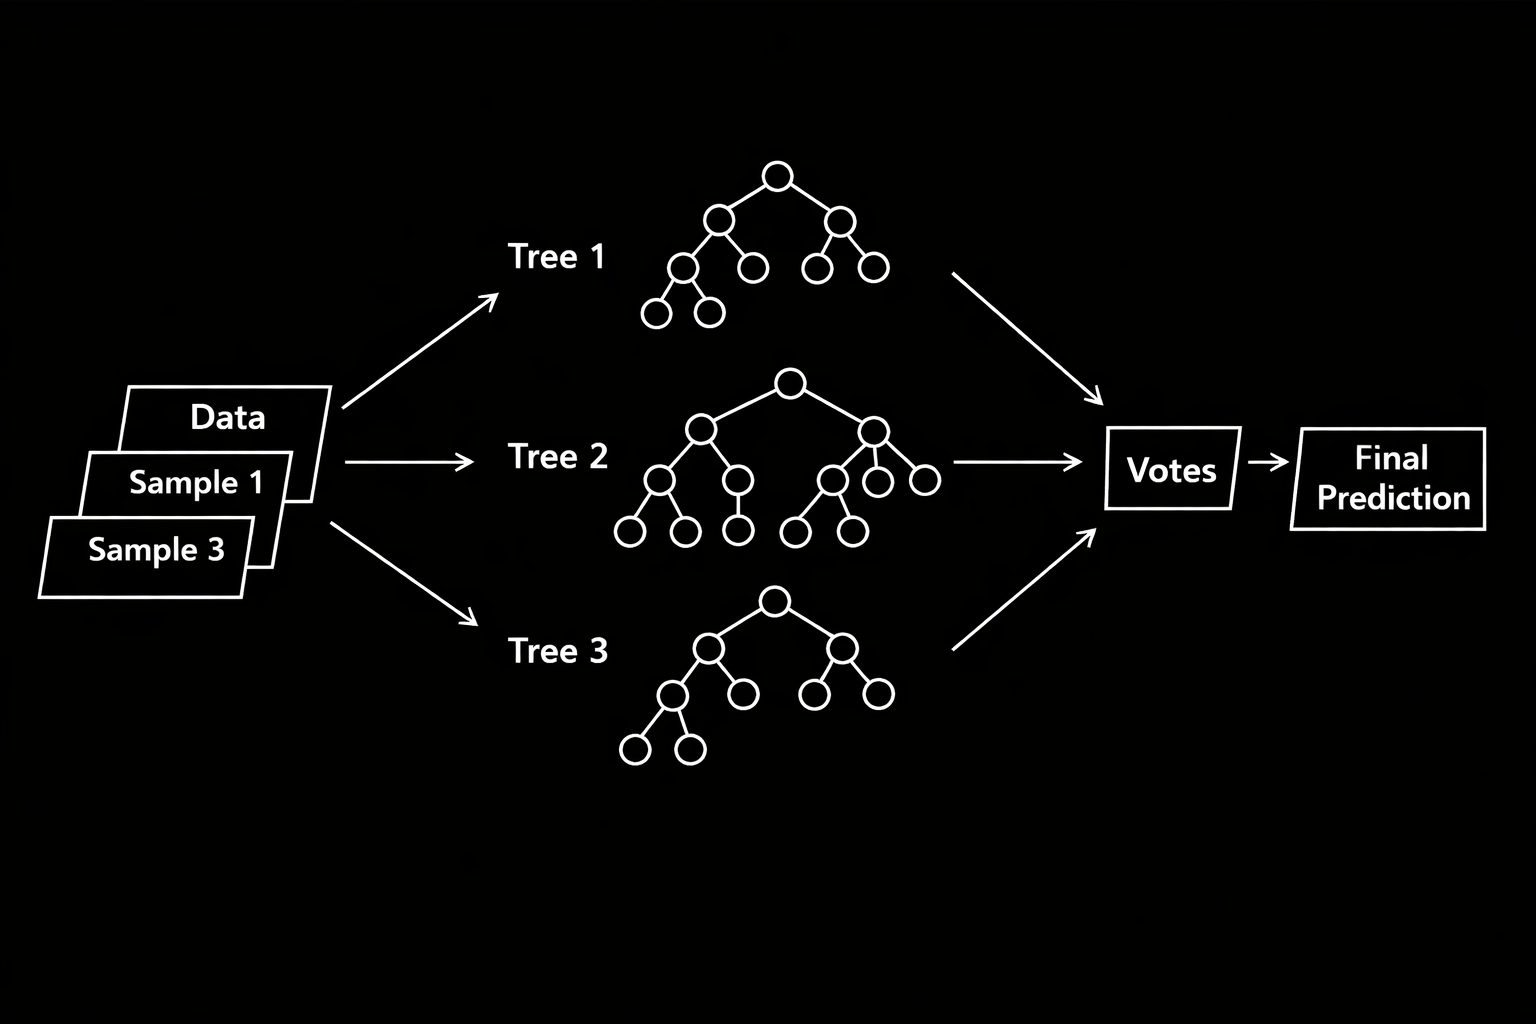

In [ ]:

k = 5
repetitions = 100

fold_results = []

for i in trange(repetitions):

    cv = KFold(n_splits=k, shuffle=True, random_state=i)
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):

        X_train, X_val = X.iloc[train_idx,:], X.iloc[val_idx,:]
        y_train, y_val = y[train_idx], y[val_idx]

        ## Train model
        RF_model = RandomForestClassifier(n_estimators=100, max_depth=3,random_state=42)
        RF_model.fit(X_train, y_train)

        ### Prediction on internal validation data
        y_pred = RF_model.predict(X_val)
        y_pred_prob = RF_model.predict_proba(X_val)
        auc_val = roc_auc_score(y_val, y_pred_prob[:,1])
        fold_results.append(auc_val)

fold_array = np.array(fold_results)
print(f"\nMedian CV AUC: {np.quantile(fold_array, 0.5)}")
print(f"Mean CV AUC: {np.mean(fold_array)}")
print(f"CV AUC STD: {np.std(fold_array)}")

### Bayesian search

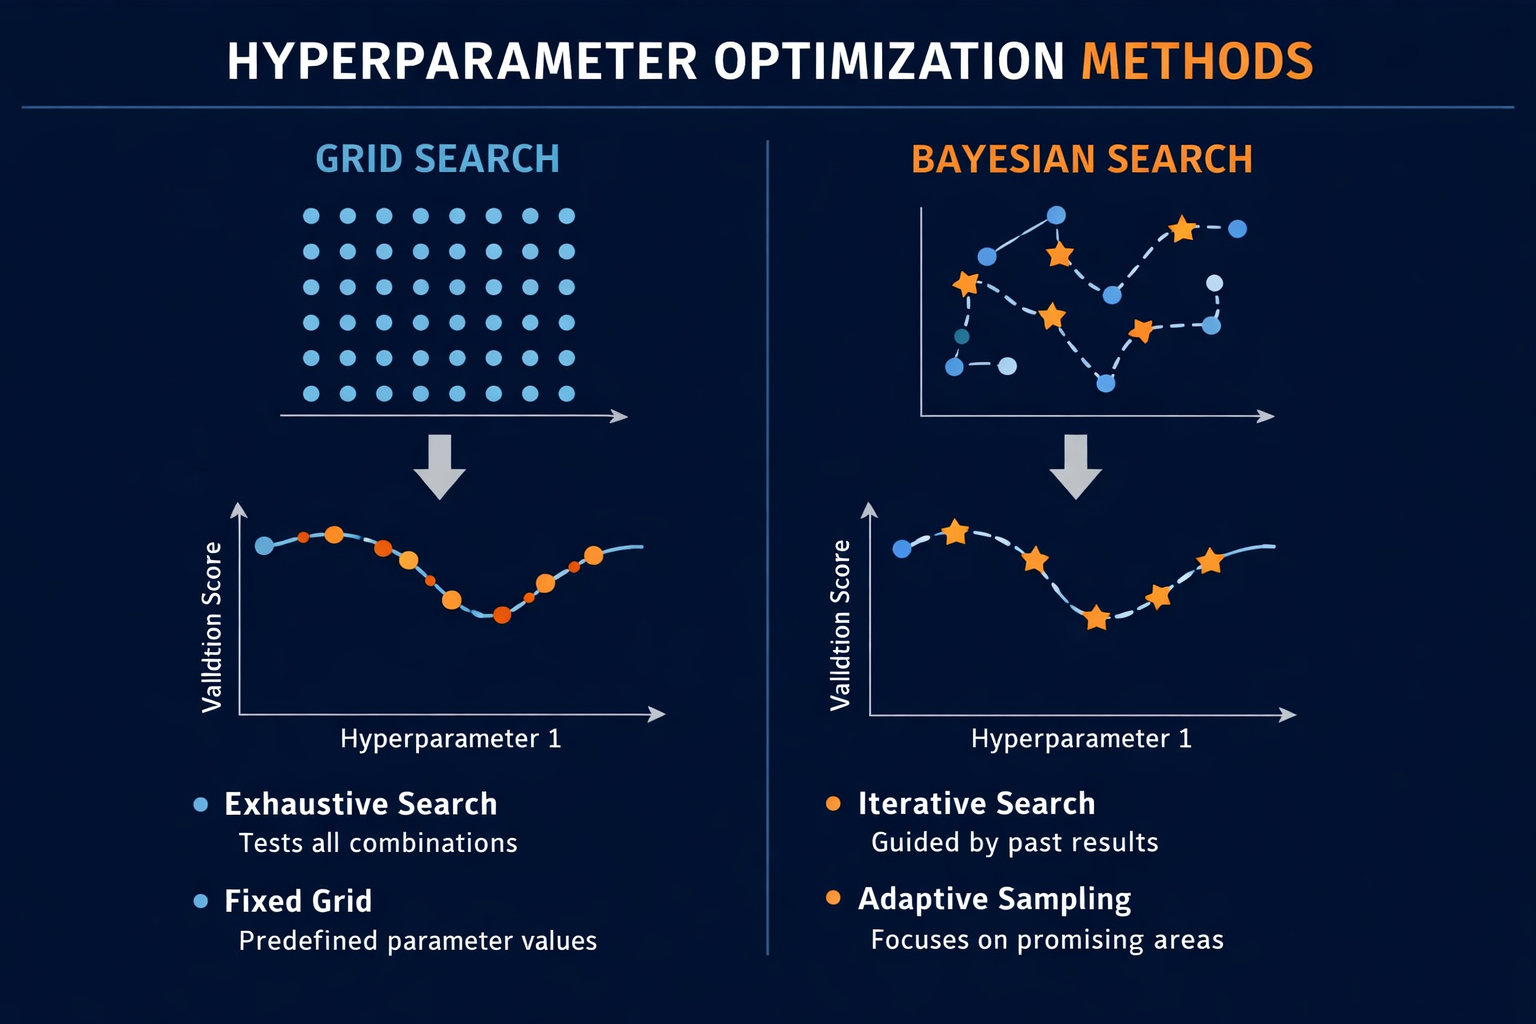

In [ ]:
# Define the search space
start = time.time()


parameters_rf = {'n_estimators': list(range(10,400,5)), 'criterion':['gini', 'entropy'], 'max_depth': list(range(2,20)),
              'min_samples_split': list(range(2,20)), 'min_samples_leaf': list(range(2,20)), 'max_leaf_nodes': list(range(2,20)),
              'class_weight' :['balanced']}


RF_model = RandomForestClassifier(random_state=42)

opt_rf = BayesSearchCV(
    estimator=RF_model,
    search_spaces=parameters_rf,
    n_iter=50,  # Number of combinations to test
    cv=5,       # Number of folds in cross-validation
    n_jobs=-1,  # Use all available cores
    random_state=42,
    verbose=0)

# Run the search
opt_rf.fit(X, y)

end = time.time()

print("Execution time: {} seconds".format(round(end - start,3)))

In [ ]:
opt_rf.best_params_

#### Application of hyperparameters found with BayesianSearch

In [ ]:

k = 5
repetitions = 100

fold_results = []

for i in trange(repetitions):

    cv = KFold(n_splits=k, shuffle=True, random_state=i)
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):

        X_train, X_val = X.iloc[train_idx,:], X.iloc[val_idx,:]
        y_train, y_val = y[train_idx], y[val_idx]

        ## Train model
        RF_model = RandomForestClassifier(**opt_rf.best_params_, random_state=42)

        RF_model.fit(X_train, y_train)

        ### Prediction on internal validation data
        y_pred = RF_model.predict(X_val)
        y_pred_prob = RF_model.predict_proba(X_val)
        auc_val = roc_auc_score(y_val, y_pred_prob[:,1])
        fold_results.append(auc_val)

fold_array = np.array(fold_results)
print(f"\nMedian CV AUC: {np.quantile(fold_array, 0.5)}")
print(f"Mean CV AUC: {np.mean(fold_array)}")
print(f"CV AUC STD: {np.std(fold_array)}")

In [ ]:
### Full results
RF_model = RandomForestClassifier(**opt_rf.best_params_, random_state=42)

rf_results_df = run_stratified_kfold(iterations=10, num_folds=5, X=X, y= y, model=RF_model)
rf_results_df.median(axis=0)


### Evaluation on the full dataset with filters

In [ ]:
print("Filas:",df_filters.shape[0] )
print("Dimensiones:", df_filters.shape[1])

In [ ]:
df_filters.head(3)

In [ ]:
y = df_filters.EGFR_mutation_status_Mutant
X_filters = df_filters.drop(columns=['EGFR_mutation_status_Mutant'])

In [ ]:
### Univariate filtering

target_col = 'EGFR_mutation_status_Mutant'

results_repeated_scaled_filters = univariate_logistic_repeated_auc_scaled(
    df=df_filters,
    target_col=target_col,
    feature_cols=X_filters.columns,
    n_splits=20, ## repetitions
    test_size=0.30,
    random_state=42,
    scaler_method='standard',   # 'standard', 'minmax', or 'robust'
    min_train_n=20,
    min_test_n=10,
    dropna=True,
    verbose=False
)

results_repeated_scaled_filters.head(5)

In [ ]:
threshold = 0.65

features_univariate_filter2 = results_repeated_scaled_filters[results_repeated_scaled_filters.mean_AUC_test > threshold].feature.to_list()
print("Number of variables seleccionadas:",len(features_univariate_filter2))
print("\n\nVariables:\n\n",features_univariate_filter2)

In [ ]:
### Baseline model with all filtered variables.

X_filters_selected = X_filters.loc[:,features_univariate_filter2]

k = 5
repetitions = 10

fold_results = []

for i in trange(repetitions):

    cv = KFold(n_splits=k, shuffle=True, random_state=i)
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_filters_selected, y), start=1):

        X_train, X_val = X_filters_selected.iloc[train_idx,:], X_filters_selected.iloc[val_idx,:]
        y_train, y_val = y[train_idx], y[val_idx]

        ## Train model
        RF_model = RandomForestClassifier(n_estimators=100,max_depth=3,random_state=42)
        RF_model.fit(X_train, y_train)

        ### Prediction on internal validation data
        y_pred = RF_model.predict(X_val)
        y_pred_prob = RF_model.predict_proba(X_val)
        auc_val = roc_auc_score(y_val, y_pred_prob[:,1])
        fold_results.append(auc_val)

fold_array = np.array(fold_results)
print(f"\nMedian CV AUC: {np.quantile(fold_array, 0.5)}")
print(f"Mean CV AUC: {np.mean(fold_array)}")
print(f"CV AUC STD: {np.std(fold_array)}")

In [ ]:
feature_name_vector = []

for feature in results_repeated_scaled_filters.feature:

  feature_name = "_".join(feature.split('_')[-2:])
  feature_name_vector.append(feature_name)
df_features_auc = results_repeated_scaled_filters.copy()
df_features_auc['original_feature_name'] =feature_name_vector

In [ ]:
df_features_auc.head(10)

In [ ]:
best_of_groups = []

for feature_group in df_features_auc.original_feature_name.unique():

  df_temp = df_features_auc[df_features_auc.original_feature_name == feature_group]
  df_temp = df_temp.sort_values(by="median_AUC_test",ascending=False).reset_index(drop=True)

  #print(feature_group, ':', df_temp.shape)
  best_of_groups.append(df_temp.feature.iloc[0])

In [ ]:
## Baseline model with all filtered variables.

X_filters_selected = X_filters.loc[:,best_of_groups]

k = 5
repetitions = 100

fold_results = []

for i in trange(repetitions):

    cv = KFold(n_splits=k, shuffle=True, random_state=i)
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_filters_selected, y), start=1):

        X_train, X_val = X_filters_selected.iloc[train_idx,:], X_filters_selected.iloc[val_idx,:]
        y_train, y_val = y[train_idx], y[val_idx]

        ## Train model
        RF_model = RandomForestClassifier(n_estimators=100,max_depth=3,random_state=42)
        RF_model.fit(X_train, y_train)

        ### Prediction on internal validation data
        y_pred = RF_model.predict(X_val)
        y_pred_prob = RF_model.predict_proba(X_val)
        auc_val = roc_auc_score(y_val, y_pred_prob[:,1])
        fold_results.append(auc_val)

fold_array = np.array(fold_results)
print(f"\nMedian CV AUC: {np.quantile(fold_array, 0.5)}")
print(f"Mean CV AUC: {np.mean(fold_array)}")
print(f"CV AUC STD: {np.std(fold_array)}")

### Class imbalance

In [ ]:
### Visualization of EGFR non-mutated / mutated cases by split:

k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=seed)

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_filters_selected, y), start=1):
    print(f"Fold: {fold_idx}")
    print(f"Total number of cases: {X_filters_selected.iloc[train_idx,:].shape[0]}")
    print(f"Distribution of patients with EGFR wildtype/mutated {Counter(y.iloc[train_idx])}")

In [ ]:
from imblearn.over_sampling import SMOTENC

categorical_features = ['Gender_Female', 'Ethnicity_Caucasian',
       'Ethnicity_Native_Hawaiian/Pacific_Islander',
       'Ethnicity_African_American', 'Ethnicity_Asian',
       'Ethnicity_Hispanic/Latino', 'Smoking_status_Nonsmoker']

# categorical column indices
categorical_features_position = list(np.where(X_filters_selected.columns.isin(categorical_features))[0])

smote_nc = SMOTENC(
    categorical_features=categorical_features_position,
    sampling_strategy=0.8,
    k_neighbors = 3,
    random_state=42)

k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=seed)

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_filters_selected, y), start=1):
    print(f"Fold: {fold_idx}")
    X_train, X_val = X_filters_selected.iloc[train_idx,:], X_filters_selected.iloc[val_idx,:]
    y_train, y_val = y[train_idx], y[val_idx]

    print(f"Total number of cases: {X_train.shape[0]}")
    print(f"y_train: Distribution of patients with EGFR wildtype/mutated {Counter(y_train)}")
    X_resampled, y_resampled = smote_nc.fit_resample(X_train, y_train)

    print(f"y_train SMOTENC: Distribution of patients with EGFR wildtype/mutated {Counter(y_resampled)}")
    print(f"y_val: Distribution of patients with EGFR wildtype/mutated {Counter(y_val)}")



In [ ]:
categorical_features = ['Gender_Female', 'Ethnicity_Caucasian',
       'Ethnicity_Native_Hawaiian/Pacific_Islander',
       'Ethnicity_African_American', 'Ethnicity_Asian',
       'Ethnicity_Hispanic/Latino', 'Smoking_status_Nonsmoker']

X_filters_selected = X_filters.loc[:,best_of_groups]

categorical_features_position = list(np.where(X_filters_selected.columns.isin(categorical_features))[0])

k = 5
repetitions = 100

fold_results = []

for i in trange(repetitions):

    cv = KFold(n_splits=k, shuffle=True, random_state=i)
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_filters_selected, y), start=1):

        X_train, X_val = X_filters_selected.iloc[train_idx,:], X_filters_selected.iloc[val_idx,:]
        y_train, y_val = y[train_idx], y[val_idx]


        smote_nc = SMOTENC(
                    categorical_features=categorical_features_position,
                    sampling_strategy=0.7,
                    k_neighbors = 6,
                    random_state=42)

        X_resampled, y_resampled = smote_nc.fit_resample(X_train, y_train)

        ## Train model
        RF_model = RandomForestClassifier(n_estimators=100,max_depth=3,random_state=42)
        RF_model.fit(X_resampled, y_resampled)

        ### Prediction on internal validation data
        y_pred = RF_model.predict(X_val)
        y_pred_prob = RF_model.predict_proba(X_val)
        auc_val = roc_auc_score(y_val, y_pred_prob[:,1])
        fold_results.append(auc_val)

fold_array = np.array(fold_results)
print(f"\nMedian CV AUC: {np.quantile(fold_array, 0.5)}")
print(f"Mean CV AUC: {np.mean(fold_array)}")
print(f"CV AUC STD: {np.std(fold_array)}")